# Notebook 06 — Investimenti SNAI e Impatto sui Territori
**Capstone: Aree Interne Italiane** | Gianluca Tommasino — Aprile 2026

Fonte principale: OpenCoesione — *Progetti esteso 2014-2020* (aggiornamento 31/12/2025)

La domanda che voglio esplorare in questo notebook e semplice:
i fondi SNAI hanno fatto differenza? E dove?

Non e una risposta facile — lo spopolamento continua ovunque, con o senza finanziamenti.
Ma guardando i dati da vicino si vedono alcune cose interessanti,
soprattutto quando si confrontano le aree che hanno ricevuto una **strategia strutturata**
con quelle che hanno ricevuto solo piccoli contributi automatici,
e con quelle che non hanno ricevuto nulla.

> *I dataset utilizzati sono stati costruiti nei notebook precedenti.
> Il file principale e `impact_analysis_powerbi.csv`, che unisce classificazione SNAI,
> finanziamenti 2014-2020, variazione demografica 2018-2023 e reddito IRPEF 2018-2022.*

In [1]:
import os
os.chdir(r'C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2')
print("Working directory:", os.getcwd())

Working directory: C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "data/processed/"
OUTPUT_DIR    = "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Palette coerente con gli altri notebook
C_DARK   = "#1F4E79"
C_MED    = "#2E75B6"
C_LIGHT  = "#9DC3E6"
C_ORANGE = "#F4A460"
C_BROWN  = "#CD853F"
C_GREEN  = "#4CAF50"
C_RED    = "#E53935"

print("Setup OK")

Setup OK


## 1. Caricamento dei dati

`impact_analysis_powerbi.csv` e il dataset aggregato che contiene,
per ciascuno dei 7.894 comuni italiani:
- classificazione SNAI (classe, tipo_area, nome area strategica)
- finanziamenti ricevuti nel ciclo 2014-2020
- variazione della popolazione 2018-2023
- variazione del reddito medio IRPEF 2018-2022
- flag di inclusione nella programmazione 2021-2027

Lavoriamo solo sui comuni classificati come Aree Interne (classe D, E, F).

In [3]:
df_all = pd.read_csv(PROCESSED_DIR + "impact_analysis_powerbi.csv", dtype=str)

# Conversione numerica
num_cols = [
    "pop_2018","pop_2023","pop_2026","var_pct_18_23","var_pct_18_26","var_pct_23_26",
    "reddito_2018","reddito_2022","var_reddito_18_22",
    "finanz_totale_1420","pagamenti_1420","n_progetti_1420",
    "n_strategia_1420","ha_finanziamento_1420","tempi_percorrenza_min"
]
for c in num_cols:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# Solo Aree Interne D/E/F
ai = df_all[df_all["is_area_interna"] == "1"].copy()

print(f"Comuni Aree Interne: {len(ai)}")
print(f"Di cui con finanziamento 14-20: {ai['ha_finanziamento_1420'].sum():.0f}")
print(f"Con nome area SNAI assegnato: {ai['nome_area_snai'].notna().sum()}")
print(f"Inclusi nella programmazione 21-27: {(ai['programmazione_2127']=='True').sum()}")
ai[["comune","regione","tipo_area","gruppo_intervento",
    "finanz_totale_1420","var_pct_18_26","var_reddito_18_22"]].head(8)

Comuni Aree Interne: 3564
Di cui con finanziamento 14-20: 2289
Con nome area SNAI assegnato: 1696
Inclusi nella programmazione 21-27: 694


,comune,regione,tipo_area,gruppo_intervento,finanz_totale_1420,var_pct_18_26,var_reddito_18_22
2,Ala di Stura,Piemonte,Periferico,Contributi automatici,17726.64,5.882,16.87
5,Alpette,Piemonte,Periferico,Contributi automatici,35130.00,-4.472,9.84
9,Angrogna,Piemonte,Intermedio,Contributi automatici,38195.00,-7.889,9.49
14,Balangero,Piemonte,Intermedio,Nessun finanziamento,0.00,-2.520,10.79
17,Balme,Piemonte,Ultraperiferico,Nessun finanziamento,0.00,-14.159,18.15
19,Barbania,Piemonte,Intermedio,Contributi automatici,75362.00,-0.192,8.00
20,Bardonecchia,Piemonte,Periferico,Nessun finanziamento,0.00,-9.140,8.64
24,Bobbio Pellice,Piemonte,Intermedio,Contributi automatici,18892.00,-2.768,9.09


## 2. Quanti soldi, dove

Prima di ragionare sull'impatto e utile capire la distribuzione dei finanziamenti.
I dati OpenCoesione 2014-2020 mostrano tre tipologie di intervento molto diverse tra loro:

- **Strategia strutturata** (247 comuni): veri accordi di programma SNAI,
  con progettualita specifica per area, media ~700K per comune
- **Contributi automatici** (2.042 comuni): piccoli trasferimenti standardizzati
  assegnati automaticamente ai comuni delle Aree Interne, media ~160K
- **Nessun finanziamento** (1.275 comuni): classificati come Aree Interne
  ma non raggiunti da nessuno dei due strumenti

Riepilogo per gruppo di intervento:
    gruppo_intervento  n_comuni  finanz_medio   finanz_tot   pagato_tot  perc_pagato
Strategia strutturata       247 703327.378138 173721862.40  55250447.96         31.8
Contributi automatici      2042 160124.682542 326974601.75 149410359.68         45.7
 Nessun finanziamento      1275      0.000000         0.00         0.00          NaN


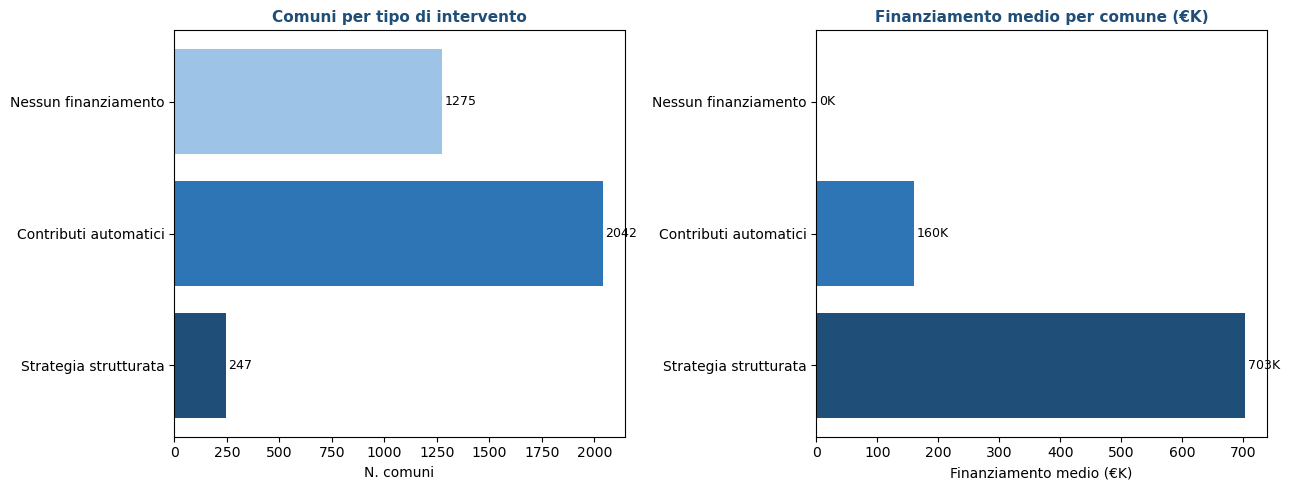

In [4]:
ORDER = ["Strategia strutturata", "Contributi automatici", "Nessun finanziamento"]
ord_map = {v: i for i, v in enumerate(ORDER)}

gruppo_stats = ai.groupby("gruppo_intervento").agg(
    n_comuni         = ("codice_comune", "count"),
    finanz_medio     = ("finanz_totale_1420", "mean"),
    finanz_tot       = ("finanz_totale_1420", "sum"),
    pagato_tot       = ("pagamenti_1420", "sum"),
).reset_index()
gruppo_stats["_ord"] = gruppo_stats["gruppo_intervento"].map(ord_map)
gruppo_stats = gruppo_stats.sort_values("_ord").drop(columns=["_ord"])
gruppo_stats["perc_pagato"] = (
    gruppo_stats["pagato_tot"] / gruppo_stats["finanz_tot"] * 100
).round(1)

print("Riepilogo per gruppo di intervento:")
print(gruppo_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico 1: n comuni per gruppo
labels = [str(v) for v in gruppo_stats["gruppo_intervento"].tolist()]
vals_n = [float(v) for v in gruppo_stats["n_comuni"].tolist()]
colors_g = [C_DARK, C_MED, C_LIGHT]
axes[0].barh(labels, vals_n, color=colors_g)
axes[0].set_xlabel("N. comuni")
axes[0].set_title("Comuni per tipo di intervento",
                  fontsize=11, fontweight="bold", color=C_DARK)
for i, v in enumerate(vals_n):
    axes[0].text(v + 10, i, f"{v:.0f}", va="center", fontsize=9)

# Grafico 2: finanziamento medio
vals_f = [float(v)/1000 for v in gruppo_stats["finanz_medio"].tolist()]
axes[1].barh(labels, vals_f, color=colors_g)
axes[1].set_xlabel("Finanziamento medio (€K)")
axes[1].set_title("Finanziamento medio per comune (€K)",
                  fontsize=11, fontweight="bold", color=C_DARK)
for i, v in enumerate(vals_f):
    axes[1].text(v + 5, i, f"{v:.0f}K", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_gruppi_intervento.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Il problema del confronto diretto

Prima di analizzare i KPI e necessario fare una premessa metodologica.

I comuni finanziati dalla SNAI **non sono un campione casuale** delle Aree Interne:
sono stati selezionati esattamente perche piu marginali, piu lontani dai servizi,
con dinamiche demografiche gia negative prima dell'intervento.

Quindi un confronto grezzo "finanziati vs non finanziati" rischia di produrre
la conclusione paradossale che i finanziamenti abbiano peggiorato le cose.

Per questo distinguiamo tre livelli di lettura:
1. confronto diretto (con tutte le sue limitazioni)
2. analisi per tipo_area (controllando la marginalita)
3. analisi per area strategica nominata (il livello a cui la SNAI ragiona davvero)

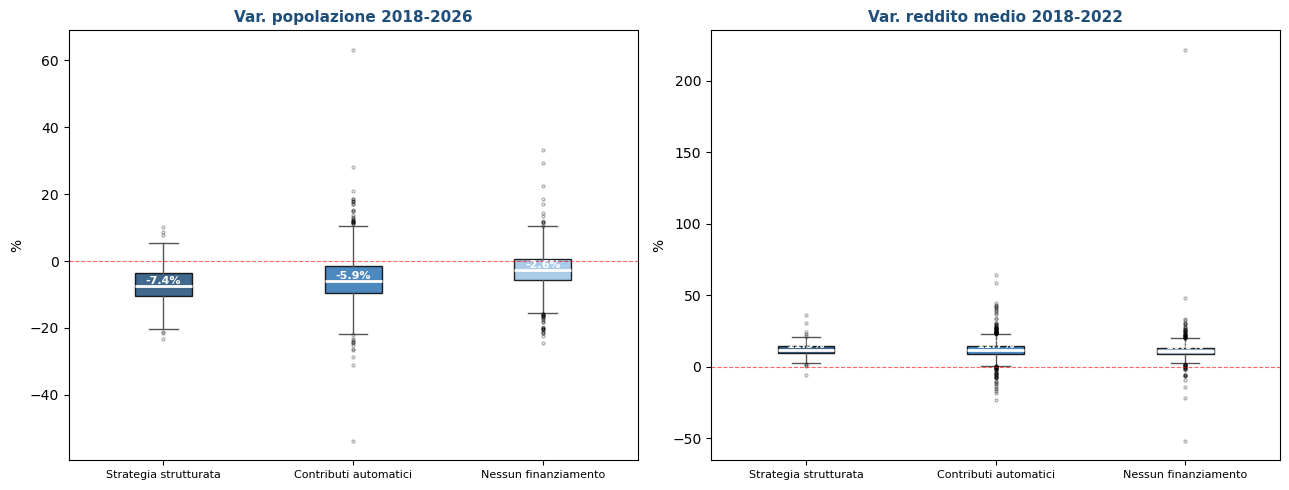

Mediane per gruppo:
  Strategia strutturata        pop_var:-7.43%  redd_var:+11.54%  pop_mediana:2017 ab.
  Contributi automatici        pop_var:-5.90%  redd_var:+11.69%  pop_mediana:1140 ab.
  Nessun finanziamento         pop_var:-2.57%  redd_var:+10.82%  pop_mediana:3870 ab.


In [5]:
# Confronto diretto: variazione popolazione per gruppo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_g = {"Strategia strutturata": C_DARK,
            "Contributi automatici": C_MED,
            "Nessun finanziamento":  C_LIGHT}

for ax, kpi, titolo, unita in zip(
    axes,
    ["var_pct_18_26", "var_reddito_18_22"],
    ["Var. popolazione 2018-2026", "Var. reddito medio 2018-2022"],
    ["%", "%"]
):
    data_plot = []
    labels_plot = []
    cols_plot = []
    for g in ORDER:
        vals = ai[ai["gruppo_intervento"] == g][kpi].dropna()
        data_plot.append(vals.tolist())
        labels_plot.append(g)
        cols_plot.append(colors_g[g])

    bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                    medianprops={"color":"white","linewidth":2},
                    whiskerprops={"color":"#555"},
                    capprops={"color":"#555"},
                    flierprops={"marker":"o","markersize":2,"alpha":0.3})
    for patch, col in zip(bp["boxes"], cols_plot):
        patch.set_facecolor(col)
        patch.set_alpha(0.85)

    ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title(titolo, fontsize=11, fontweight="bold", color=C_DARK)
    ax.set_ylabel(unita)
    ax.tick_params(axis="x", labelsize=8)

    # Aggiunge la mediana come annotazione
    for i, g in enumerate(ORDER):
        med = ai[ai["gruppo_intervento"] == g][kpi].median()
        ax.text(i+1, med, f"{med:.1f}%", ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_confronto_kpi_diretto.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mediane per gruppo:")
for g in ORDER:
    sub = ai[ai["gruppo_intervento"] == g]
    vp = sub["var_pct_18_26"].median()
    vr = sub["var_reddito_18_22"].median()
    pop_med = sub["pop_2018"].median()
    print(f"  {g:<28} pop_var:{vp:+.2f}%  redd_var:{vr:+.2f}%  pop_mediana:{pop_med:.0f} ab.")

## 4. Controllando per marginalita: analisi per tipo_area

Dividendo per tipo_area (Intermedio / Periferico / Ultraperiferico)
confrontiamo comuni con livelli simili di marginalita.
In questo modo il confronto tra finanziati e non finanziati e piu equo.

La domanda diventa: a parita di classe SNAI,
i comuni che hanno ricevuto finanziamenti si comportano diversamente?

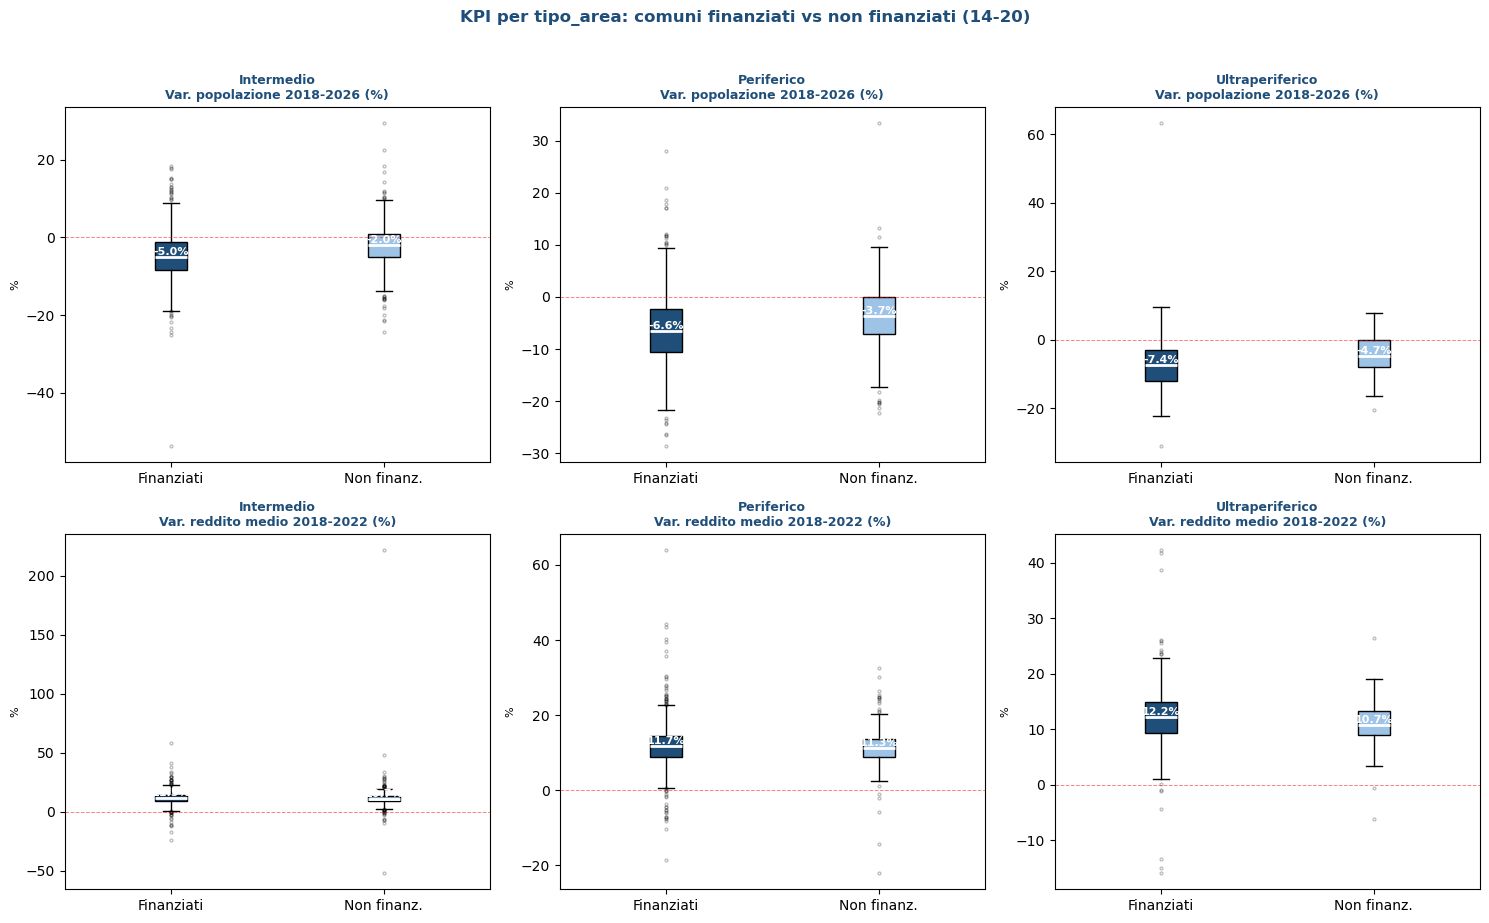

In [6]:
tipo_order = ["Intermedio", "Periferico", "Ultraperiferico"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

kpi_list = [
    ("var_pct_18_26",     "Var. popolazione 2018-2026 (%)",    "%"),
    ("var_reddito_18_22", "Var. reddito medio 2018-2022 (%)",  "%"),
]

for row, (kpi, titolo, unita) in enumerate(kpi_list):
    for col, ta in enumerate(tipo_order):
        ax = axes[row][col]
        sub = ai[ai["tipo_area"] == ta]

        # Solo finanziati vs non finanziati (esclude "nessun finanziamento" per leggibilita)
        g_fin = sub[sub["ha_finanziamento_1420"] == 1][kpi].dropna().tolist()
        g_no  = sub[sub["ha_finanziamento_1420"] == 0][kpi].dropna().tolist()

        bp = ax.boxplot([g_fin, g_no],
                        labels=["Finanziati", "Non finanz."],
                        patch_artist=True,
                        medianprops={"color":"white","linewidth":2},
                        flierprops={"marker":"o","markersize":2,"alpha":0.25})
        bp["boxes"][0].set_facecolor(C_DARK)
        bp["boxes"][1].set_facecolor(C_LIGHT)

        ax.axhline(0, color="red", linestyle="--", linewidth=0.7, alpha=0.5)
        ax.set_title(f"{ta}\n{titolo}", fontsize=9, fontweight="bold", color=C_DARK)
        ax.set_ylabel(unita, fontsize=8)

        # Annotazioni mediana
        for i, vals in enumerate([g_fin, g_no]):
            if vals:
                med = float(np.median(vals))
                ax.text(i+1, med, f"{med:.1f}%", ha="center", va="bottom",
                        fontsize=8, fontweight="bold", color="white")

plt.suptitle("KPI per tipo_area: comuni finanziati vs non finanziati (14-20)",
             fontsize=12, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_kpi_per_tipo_area.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Finanziamento per tema: dove sono andati i soldi

OpenCoesione classifica ogni progetto per tema sintetico.
Guardare dove si e investito di piu aiuta a capire le priorita della strategia
e anche dove c'e ancora gap tra impegno e pagamenti effettuati.

Nota: "Trasporti e mobilita" ha cifre molto alte perche include pochi grandi appalti
infrastrutturali aggregati su piu comuni. Non e cosi rappresentativo
della logica tipica SNAI (che preferisce interventi diffusi e locali).

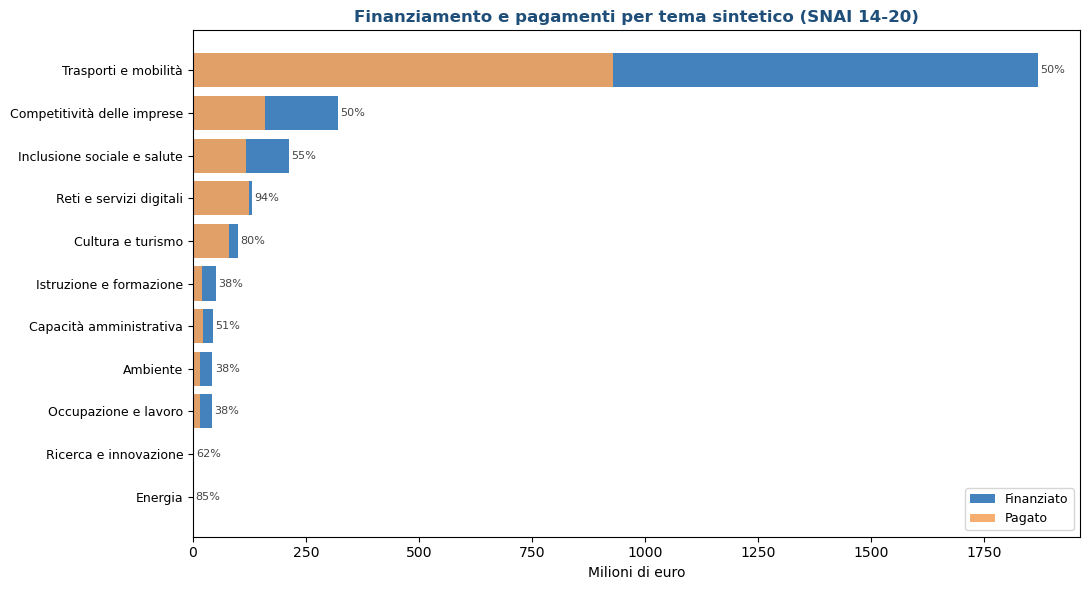

In [7]:
df_tema = pd.read_csv(PROCESSED_DIR + "opencoesione_snai_per_tema.csv")
df_tema = df_tema.sort_values("finanz_totale", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

labels_t = [str(v) for v in df_tema["OC_TEMA_SINTETICO"].tolist()]
vals_fin  = [float(v)/1e6 for v in df_tema["finanz_totale"].tolist()]
vals_pag  = [float(v)/1e6 for v in df_tema["pagamenti"].tolist()]

y = range(len(labels_t))
ax.barh(list(y), vals_fin, color=C_MED,    label="Finanziato",  alpha=0.9)
ax.barh(list(y), vals_pag, color=C_ORANGE, label="Pagato",      alpha=0.9)

ax.set_yticks(list(y))
ax.set_yticklabels(labels_t, fontsize=9)
ax.set_xlabel("Milioni di euro", fontsize=10)
ax.set_title("Finanziamento e pagamenti per tema sintetico (SNAI 14-20)",
             fontsize=12, fontweight="bold", color=C_DARK)
ax.legend(fontsize=9)

# % pagato come annotazione
for i, (f, p) in enumerate(zip(vals_fin, vals_pag)):
    if f > 0:
        pct = p/f*100
        ax.text(max(f, p) + 5, i, f"{pct:.0f}%", va="center", fontsize=8, color="#444")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_finanziamenti_per_tema.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Le aree strategiche: chi ha investito di piu e cosa e cambiato

Le aree strategiche SNAI sono il vero livello di analisi della politica:
non il singolo comune, ma il sistema di comuni che condividono una strategia.

Qui confrontiamo le 20 aree con piu risorse investite nel 14-20
con la loro performance demografica e la continuita nel 21-27.

Un dato in particolare mi ha colpito: alcune aree che hanno ricevuto
investimenti significativi non sono state rinnovate nel 21-27,
mentre altre, con risultati simili, sono state confermate.
Non e sempre ovvio capire il criterio.

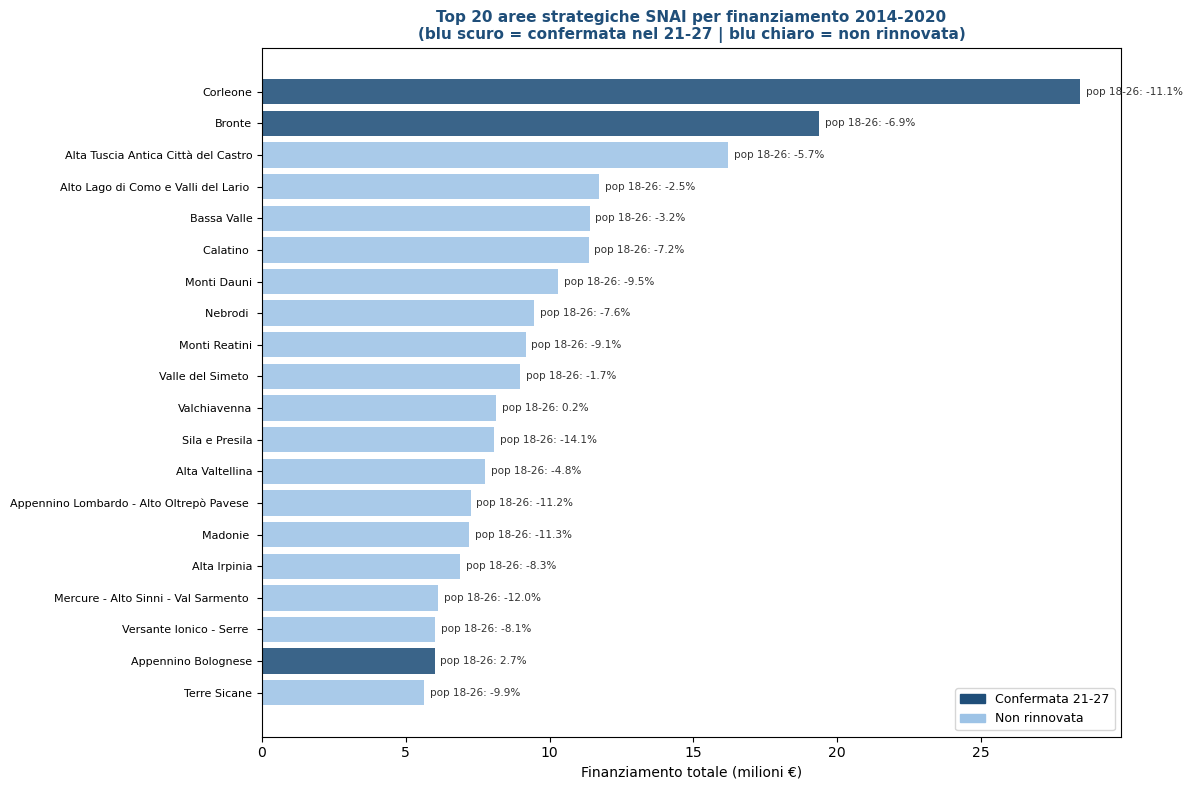

In [8]:
ai_named = ai[ai["nome_area_snai"].notna()].copy()

area_agg = ai_named.groupby("nome_area_snai").agg(
    n_comuni        = ("codice_comune",         "count"),
    finanz_tot      = ("finanz_totale_1420",     "sum"),
    pop_var_med     = ("var_pct_18_26",          "median"),
    redd_var_med    = ("var_reddito_18_22",       "median"),
    pop_2018_tot    = ("pop_2018",               "sum"),
    in_2127         = ("programmazione_2127",    lambda x: (x == "True").sum()),
    n_finanz        = ("ha_finanziamento_1420",  "sum"),
).reset_index()

area_agg["finanz_pro_comune"] = area_agg["finanz_tot"] / area_agg["n_comuni"]
area_agg["confermata_2127"]   = area_agg["in_2127"] > 0

top20 = area_agg.nlargest(20, "finanz_tot").copy()

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = range(len(top20))
labels_a = [str(v)[:45] for v in top20["nome_area_snai"].tolist()[::-1]]
vals_a   = [float(v)/1e6 for v in top20["finanz_tot"].tolist()[::-1]]
confermate = [bool(v) for v in top20["confermata_2127"].tolist()[::-1]]
pop_vars   = [float(v) for v in top20["pop_var_med"].tolist()[::-1]]

bar_colors = [C_DARK if c else C_LIGHT for c in confermate]
bars = ax.barh(list(y_pos), vals_a, color=bar_colors, alpha=0.88)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels_a, fontsize=8)
ax.set_xlabel("Finanziamento totale (milioni €)", fontsize=10)
ax.set_title("Top 20 aree strategiche SNAI per finanziamento 2014-2020\n"
             "(blu scuro = confermata nel 21-27 | blu chiaro = non rinnovata)",
             fontsize=11, fontweight="bold", color=C_DARK)

# Var. pop come annotazione
for i, (v, vp) in enumerate(zip(vals_a, pop_vars)):
    ax.text(v + 0.2, i, f"pop 18-26: {vp:.1f}%", va="center", fontsize=7.5, color="#333")

patch_si  = mpatches.Patch(color=C_DARK,  label="Confermata 21-27")
patch_no  = mpatches.Patch(color=C_LIGHT, label="Non rinnovata")
ax.legend(handles=[patch_si, patch_no], fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_top20_aree_finanziamento.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Distanza dal polo e finanziamenti ricevuti

La variabile `tempi_percorrenza_min` misura quanto dista (in minuti di viaggio)
ogni comune dal polo di riferimento piu vicino.
E una misura diretta di quanto e "interno" un territorio.

Mi interessa capire se la distanza dal polo predice la quantita di finanziamenti ricevuti.
In teoria i comuni piu lontani (ultraperiferici) dovrebbero essere quelli
con maggiore necessita di intervento — ma sono anche i piu difficili da raggiungere
con progetti strutturati.

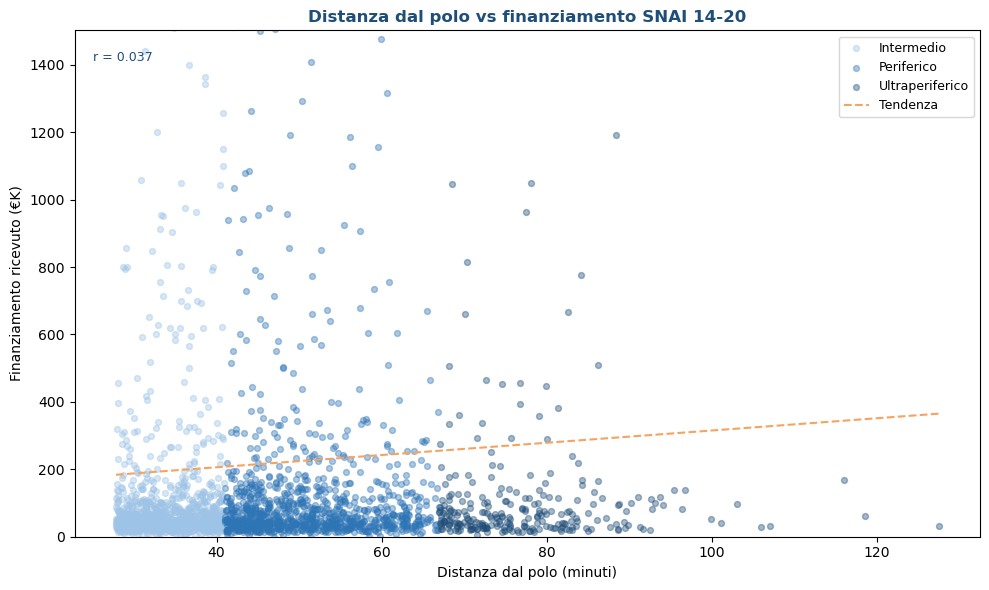

Correlazione distanza-finanziamento: 0.037


In [9]:
ai_dist = ai[
    ai["tempi_percorrenza_min"].notna() &
    ai["finanz_totale_1420"].notna() &
    (ai["finanz_totale_1420"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

color_map = {"Intermedio": C_LIGHT, "Periferico": C_MED, "Ultraperiferico": C_DARK}
for ta, grp in ai_dist.groupby("tipo_area"):
    col = color_map.get(str(ta), "#aaa")
    ax.scatter(
        grp["tempi_percorrenza_min"].astype(float),
        grp["finanz_totale_1420"].astype(float) / 1000,
        c=col, alpha=0.4, s=18, label=str(ta)
    )

# Linea di tendenza semplice
x = ai_dist["tempi_percorrenza_min"].astype(float)
y = ai_dist["finanz_totale_1420"].astype(float) / 1000
valid = x.notna() & y.notna()
z = np.polyfit(x[valid], y[valid], 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), "--", color=C_ORANGE, linewidth=1.5, label="Tendenza")

ax.set_xlabel("Distanza dal polo (minuti)", fontsize=10)
ax.set_ylabel("Finanziamento ricevuto (€K)", fontsize=10)
ax.set_title("Distanza dal polo vs finanziamento SNAI 14-20",
             fontsize=12, fontweight="bold", color=C_DARK)
ax.legend(fontsize=9)
ax.set_ylim(0, ai_dist["finanz_totale_1420"].astype(float).quantile(0.97) / 1000)

corr = x[valid].corr(y[valid])
ax.text(0.02, 0.96, f"r = {corr:.3f}", transform=ax.transAxes,
        fontsize=9, va="top", color=C_DARK)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_distanza_vs_finanziamento.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlazione distanza-finanziamento: {corr:.3f}")

## 8. Chi e entrato nel 21-27: continuita o discontinuita?

Delle 3.564 Aree Interne, solo 694 sono state incluse nella nuova programmazione 2021-2027.
Questo e un criterio di selezione importante: quali caratteristiche hanno i comuni
che sono stati rinnovati rispetto a quelli usciti dalla strategia?

Tre variabili su cui mi concentro:
- avevano gia ricevuto finanziamenti nel 14-20?
- la loro popolazione stava calando piu o meno degli altri?
- il reddito era cresciuto di piu o di meno?

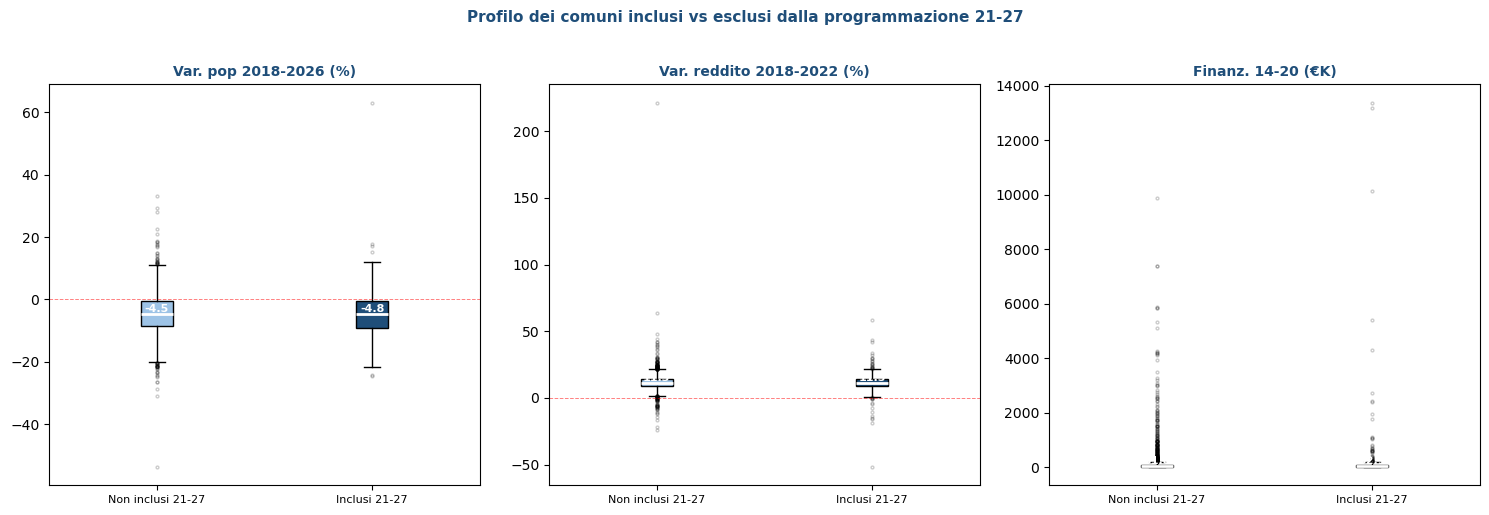

Non inclusi 21-27 (n=2870):
  Gia finanziati nel 14-20:     1829 (64%)
  Var. pop mediana 2018-2026:   -4.53%
  Var. reddito mediana:          +11.30%

Inclusi 21-27 (n=694):
  Gia finanziati nel 14-20:     460 (66%)
  Var. pop mediana 2018-2026:   -4.80%
  Var. reddito mediana:          +11.48%



In [10]:
ai["flag_2127"] = ai["programmazione_2127"] == "True"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels_2127 = ["Non inclusi 21-27", "Inclusi 21-27"]
colors_2127 = [C_LIGHT, C_DARK]

for ax, kpi, titolo in zip(
    axes,
    ["var_pct_18_26", "var_reddito_18_22", "finanz_totale_1420"],
    ["Var. pop 2018-2026 (%)", "Var. reddito 2018-2022 (%)", "Finanz. 14-20 (€K)"]
):
    g0 = ai[~ai["flag_2127"]][kpi].dropna().tolist()
    g1 = ai[ ai["flag_2127"]][kpi].dropna().tolist()
    if kpi == "finanz_totale_1420":
        g0 = [v/1000 for v in g0]
        g1 = [v/1000 for v in g1]

    bp = ax.boxplot([g0, g1], labels=labels_2127, patch_artist=True,
                    medianprops={"color":"white","linewidth":2},
                    flierprops={"marker":"o","markersize":2,"alpha":0.2})
    bp["boxes"][0].set_facecolor(C_LIGHT)
    bp["boxes"][1].set_facecolor(C_DARK)

    if kpi != "finanz_totale_1420":
        ax.axhline(0, color="red", linestyle="--", linewidth=0.7, alpha=0.5)

    for i, vals in enumerate([g0, g1]):
        if vals:
            med = float(np.median(vals))
            ax.text(i+1, med, f"{med:.1f}", ha="center", va="bottom",
                    fontsize=8, fontweight="bold", color="white")

    ax.set_title(titolo, fontsize=10, fontweight="bold", color=C_DARK)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Profilo dei comuni inclusi vs esclusi dalla programmazione 21-27",
             fontsize=11, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb06_inclusione_2127.png", dpi=150, bbox_inches="tight")
plt.show()

for flag, label in [(False, "Non inclusi 21-27"), (True, "Inclusi 21-27")]:
    sub = ai[ai["flag_2127"] == flag]
    print(f"{label} (n={len(sub)}):")
    print(f"  Gia finanziati nel 14-20:     {sub['ha_finanziamento_1420'].sum():.0f} ({100*sub['ha_finanziamento_1420'].mean():.0f}%)")
    print(f"  Var. pop mediana 2018-2026:   {sub['var_pct_18_26'].median():+.2f}%")
    print(f"  Var. reddito mediana:          {sub['var_reddito_18_22'].median():+.2f}%")
    print()

---
## Riepilogo Notebook 06

Questo notebook ha analizzato i finanziamenti SNAI 2014-2020 su base comunale
e ha cercato di mettere in relazione l'investimento con le traiettorie demografiche e reddituali.

**Quello che emerge:**

I comuni piu finanziati mostrano perdite demografiche piu alte rispetto
a quelli non finanziati — ma questo non significa che i fondi abbiano fallito.
Significa che la selezione dei territori target ha funzionato: sono stati raggiunti
esattamente i comuni piu in difficolta, quelli piu piccoli e piu lontani dai servizi.

Sul reddito, la crescita e generalizzata (+10-12% tra 2018 e 2022 per tutti i gruppi),
effetto della ripresa post-Covid a livello nazionale.
I comuni con strategia strutturata mostrano una crescita leggermente superiore,
ma non e possibile isolare l'effetto SNAI da quello del ciclo economico generale.

La continuita nel 21-27 riguarda solo il 19% delle Aree Interne totali.
Chi e stato incluso aveva mediamente gia ricevuto finanziamenti nel 14-20 (66% dei casi),
confermando una logica di continuita sulle aree che avevano gia una struttura progettuale.

**Limiti dell'analisi:**
- Assenza di dati pre-2018 sui KPI (non e possibile fare un confronto before/after pulito)
- Il dataset OpenCoesione aggrega comuni anche tramite contributi automatici non SNAI
- Le variazioni demografiche e reddituali riflettono dinamiche strutturali decennali,
  non modificabili in 5-7 anni di programmazione